<a href="https://colab.research.google.com/github/akash092/MSAI_DL/blob/main/Module1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello World")

Hello World


In [1]:
import torch
import torch.distributions as dist

In [ ]:
bernoulli = dist.Bernoulli(torch.tensor([0.5]))

In [ ]:
samples = [bernoulli.sample() for _ in range(1000)]
print(f"Mean: {torch.mean(torch.stack(samples))}")
print(f"Variance: {torch.var(torch.stack(samples))}")

Mean: 0.5019999742507935
Variance: 0.2502462565898895


In [ ]:
normal = dist.Normal(torch.tensor([0.0]), torch.tensor([1.0]))
samples = [normal.sample() for _ in range(1000)]
print(f"Mean: {torch.mean(torch.stack(samples))}")
print(f"Variance: {torch.var(torch.stack(samples))}")

Mean: -0.027469173073768616
Variance: 0.910779595375061


In [2]:
import torch
import torchvision
from PIL import Image



In [ ]:
# Create a vector of zeros of size 5
size = (128, 128)
transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size), torchvision.transforms.ToTensor()])
train_dataset = list(torchvision.datasets.Flowers102("/tmp/flowers", "train", transform=transform, download=True))
test_dataset = list(torchvision.datasets.Flowers102("/tmp/flowers", "test", transform=transform, download=True))

# each data in the above dataset is composed to image details(index 0) and category (index 1)
# index 0 is a 3-d list of all the x-y coordinates with each coordinat having RGB values as a list

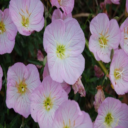

In [ ]:
def visualize_image(img: torch.Tensor) -> Image.Image:
    return Image.fromarray((img.permute(1, 2, 0) * 255).to(torch.uint8).numpy())

# print the first image
visualize_image(train_dataset[0][0])

In [1]:
class_01 = train_dataset[:20]

NameError: name 'train_dataset' is not defined

In [ ]:
def nn_classifier(x):
    dist = [((x - im).pow(2).sum(), lbl) for im, lbl in class_01]
    return min(dist)[1]

In [ ]:
classifier = nn_classifier(test_dataset[0][0])
print(classifier)


1


In [ ]:
# True is 1, False is 0. So in the below if all was right classification, accuracy will be 1
accuracy = sum(nn_classifier(im) == lbl for im,  lbl in test_dataset[:20]) / 20
print(accuracy)

0.4


In [ ]:
def knn_classifier(x, k=3):
    dist = [((x - im).pow(2).sum(), lbl) for im, lbl in class_01]
    k_closest = [lbl for _, lbl in sorted(dist)[:k]]
    return sorted(k_closest)[k // 2] # k//2 just refer to the middle element in k_closest possibility

In [ ]:
# knn_classifier(test_dataset[3][0])
accuracy = sum(knn_classifier(x) == lbl for x, lbl in test_dataset[:20]) / 20
print(accuracy)

0.5


In [ ]:
def knn_regression(x, k=3):
    dist = [((x - im).pow(2).sum(), lbl) for im, lbl in class_01]
    k_closest = [lbl for _, lbl in sorted(dist)[:k]]
    print(k_closest)
    return torch.mean(torch.tensor(k_closest).float())


knn_regression(test_dataset[3][0])

[0, 1, 1]


tensor(0.6667)

In [3]:
# a row tensor with value as 1,2,3
a=torch.tensor([1,2,3], dtype=torch.float32)
print(a, type(a))

tensor([1., 2., 3.]) <class 'torch.Tensor'>


In [4]:
# a 3x3x3 tensor with random values
b = torch.rand([3, 3, 3], dtype=torch.float32)
print(b, type(b))

tensor([[[0.8917, 0.4598, 0.9478],
         [0.2677, 0.5846, 0.1123],
         [0.2829, 0.2377, 0.6585]],

        [[0.1580, 0.0642, 0.9608],
         [0.7942, 0.4373, 0.7747],
         [0.2244, 0.2951, 0.5924]],

        [[0.6238, 0.6532, 0.4256],
         [0.3383, 0.0056, 0.1077],
         [0.4029, 0.5647, 0.5977]]]) <class 'torch.Tensor'>


In [5]:
import numpy as np
import torch
from PIL import Image



In [3]:
import os

files = os.listdir()
print(files)

['.config', 'cat.jpg', 'sample_data']


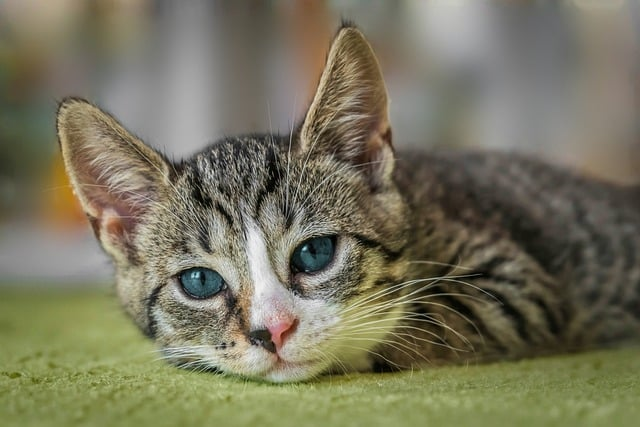

In [4]:
img = Image.open("cat.jpg")
#opens up image in the prompt
img
# opens up image in a separate window

# New Section

In [6]:
c = torch.as_tensor(np.array(img), dtype=torch.float32)
print(c.dtype)

torch.float32


In [11]:
a = torch.arange(10) # row/vector which has values sequential from 0 to n-1
b = torch.ones(10)
print(f"{a = }")
print(f"{b = }")
print(f"{a * (2 * b) = }") # dot product or one on one product
print(f"{a ** (2 * b) = }") # a^(2b) dot product or one on one product

a = tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
b = tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
a * (2 * b) = tensor([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18.])
a ** (2 * b) = tensor([ 0.,  1.,  4.,  9., 16., 25., 36., 49., 64., 81.])


In [12]:
a = torch.rand(500_000_000)
b = torch.rand(500_000_000)


In [13]:
%timeit c = a + b

1.3 s ± 139 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [14]:
a_gpu = a.to("cuda")
b_gpu = b.to("cuda")


In [15]:
%timeit c_gpu = a_gpu + b_gpu

24.4 ms ± 20.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [3]:
# check if cuda is available
# false for my linux and True for Google Colab
torch.cuda.is_available()

False

In [13]:
a = torch.arange(6)
print(f'original size:{a.shape}')
b = a.reshape(2, 3) # looks to be reshape() and view() is same in terms of copying underlying data
print(f'reshaped size:{b.shape} and {b}')

original size:torch.Size([6])
reshaped size:torch.Size([2, 3]) and tensor([[0, 1, 2],
        [3, 4, 5]])


In [16]:
a = torch.rand(2, 3, 4)
print(a.shape)
print(a)
b = a.permute(1, 2, 0) # redo the matrix where 0,1,2,..represent the ith-dimension in the original tensor
print(b.shape)
print(b)

torch.Size([2, 3, 4])
tensor([[[0.8914, 0.5005, 0.4689, 0.3150],
         [0.8311, 0.3408, 0.4402, 0.0193],
         [0.1230, 0.7484, 0.9000, 0.8340]],

        [[0.3422, 0.2610, 0.0239, 0.4181],
         [0.2367, 0.2715, 0.0724, 0.7995],
         [0.8733, 0.7108, 0.5951, 0.5082]]])
torch.Size([3, 4, 2])
tensor([[[0.8914, 0.3422],
         [0.5005, 0.2610],
         [0.4689, 0.0239],
         [0.3150, 0.4181]],

        [[0.8311, 0.2367],
         [0.3408, 0.2715],
         [0.4402, 0.0724],
         [0.0193, 0.7995]],

        [[0.1230, 0.8733],
         [0.7484, 0.7108],
         [0.9000, 0.5951],
         [0.8340, 0.5082]]])


In [23]:
a = torch.arange(6)
b = a[None,:] # None this way add an extra of size 1
print(b.shape, b)
b = a[:, None]
print(b.shape, b)
b= a[None,:,None]
print(b.shape, b)
a = a.view(3,2)
b = a[None,:,None,:]
print(b.shape, b)
b = a[..., None]
print(b.shape, b)


torch.Size([1, 6]) tensor([[0, 1, 2, 3, 4, 5]])
torch.Size([6, 1]) tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5]])
torch.Size([1, 6, 1]) tensor([[[0],
         [1],
         [2],
         [3],
         [4],
         [5]]])
torch.Size([1, 3, 1, 2]) tensor([[[[0, 1]],

         [[2, 3]],

         [[4, 5]]]])
torch.Size([3, 2, 1]) tensor([[[0],
         [1]],

        [[2],
         [3]],

        [[4],
         [5]]])


In [26]:
a = torch.arange(6).view(3, 2, 1, 1)
print(a.squeeze(-1).shape) # squeeze to remove a dimension of size 1
print(a.squeeze(0).shape) # no-op

torch.Size([3, 2, 1])
torch.Size([3, 2, 1, 1])


In [18]:
a = torch.rand(2, 3)
print(a)
b = a.mT #transpose
print(b)


tensor([[0.4925, 0.9871, 0.1575],
        [0.5298, 0.6401, 0.5655]])
tensor([[0.4925, 0.5298],
        [0.9871, 0.6401],
        [0.1575, 0.5655]])


In [31]:
a, b = torch.ones(4), torch.ones(1) # this works since torch adds smart logic to add it
print(a+b)
# torch has logic to expand along the dimension of size 1
# so in the above, b, which has size 1 is expanded to match a which has size 4
# this is called BROADCASTING
# this works for dot product/outer product as well
a, b = torch.ones(4,1), torch.ones(1, 5) 
c = a+b
print(c.shape)
print(c)

tensor([2., 2., 2., 2.])
torch.Size([4, 5]) <built-in method size of Tensor object at 0x7fe1dfe67090>
tensor([[2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.]])


In [44]:
# simple application of broadcasting
# Compute distance between all 2-d points
x = torch.rand(10,2) # 10 random points
d = torch.zeros(10,10) # end result will be stored here where for every point we will store distance to every other point

# without BROADCASTING

for i in range(10):
    for j in range(10):
        d[i,j] = (x[i]-x[j]).pow(2).sum() # x[i] - x[j] gives distance in each dimension
        # then distance in each dimension is squared and summed up to give a scalar
print(d)



tensor([[0.0000, 0.5094, 0.0287, 0.5708, 0.1005, 0.0476, 0.1521, 0.5147, 0.7628,
         0.2966],
        [0.5094, 0.0000, 0.7591, 0.0317, 0.4499, 0.3654, 0.3683, 0.6461, 0.4848,
         0.5360],
        [0.0287, 0.7591, 0.0000, 0.8024, 0.1229, 0.1417, 0.2904, 0.7177, 1.0560,
         0.4546],
        [0.5708, 0.0317, 0.8024, 0.0000, 0.4017, 0.4821, 0.5384, 0.9322, 0.7627,
         0.7701],
        [0.1005, 0.4499, 0.1229, 0.4017, 0.0000, 0.2201, 0.4032, 0.9512, 1.1411,
         0.6575],
        [0.0476, 0.3654, 0.1417, 0.4821, 0.2201, 0.0000, 0.0305, 0.2617, 0.4293,
         0.1177],
        [0.1521, 0.3683, 0.2904, 0.5384, 0.4032, 0.0305, 0.0000, 0.1159, 0.2392,
         0.0324],
        [0.5147, 0.6461, 0.7177, 0.9322, 0.9512, 0.2617, 0.1159, 0.0000, 0.0823,
         0.0301],
        [0.7628, 0.4848, 1.0560, 0.7627, 1.1411, 0.4293, 0.2392, 0.0823, 0.0000,
         0.1591],
        [0.2966, 0.5360, 0.4546, 0.7701, 0.6575, 0.1177, 0.0324, 0.0301, 0.1591,
         0.0000]])


In [46]:
# with BROADCAST
d = (x[:,None, :] - x[None, :, :]).pow(2).sum(-1) 
#[10,1,2] - [1,10,2] --> [10,10,2] since dimension with size 1 will be expanded to higher size corresponding to the same dimension in the other tensor
print(d.shape) # 10,10,2
print(d)

# TODO later is to understand the above better

torch.Size([10, 10])
tensor([[0.0000, 0.5094, 0.0287, 0.5708, 0.1005, 0.0476, 0.1521, 0.5147, 0.7628,
         0.2966],
        [0.5094, 0.0000, 0.7591, 0.0317, 0.4499, 0.3654, 0.3683, 0.6461, 0.4848,
         0.5360],
        [0.0287, 0.7591, 0.0000, 0.8024, 0.1229, 0.1417, 0.2904, 0.7177, 1.0560,
         0.4546],
        [0.5708, 0.0317, 0.8024, 0.0000, 0.4017, 0.4821, 0.5384, 0.9322, 0.7627,
         0.7701],
        [0.1005, 0.4499, 0.1229, 0.4017, 0.0000, 0.2201, 0.4032, 0.9512, 1.1411,
         0.6575],
        [0.0476, 0.3654, 0.1417, 0.4821, 0.2201, 0.0000, 0.0305, 0.2617, 0.4293,
         0.1177],
        [0.1521, 0.3683, 0.2904, 0.5384, 0.4032, 0.0305, 0.0000, 0.1159, 0.2392,
         0.0324],
        [0.5147, 0.6461, 0.7177, 0.9322, 0.9512, 0.2617, 0.1159, 0.0000, 0.0823,
         0.0301],
        [0.7628, 0.4848, 1.0560, 0.7627, 1.1411, 0.4293, 0.2392, 0.0823, 0.0000,
         0.1591],
        [0.2966, 0.5360, 0.4546, 0.7701, 0.6575, 0.1177, 0.0324, 0.0301, 0.1591,
       

In [48]:
# continuin on the above, for getting the max distance
print(d.max(), d.argmax() //10, d.argmax() % 10) 
# argmax() flattens the 2-d to 1-d thus taking quotient and remainder


tensor(1.1411) tensor(4) tensor(8)


In [49]:
a, b = torch.rand(2, 3), torch.rand(3,5)
c = a @ b # matrix multiplication
print(c.shape)

torch.Size([2, 5])


In [54]:
# norm of the tensor
a = torch.tensor([[1,2,3],[4,5,6]], dtype=torch.float32)
print(f'norm is {a.pow(2).sum().sqrt()}')
# OR
print(torch.linalg.norm(a))

norm is 9.539392471313477
tensor(9.5394)
